# Elliptic Bitcoin Fraud Detection
## Social Network Analysis — Course Project

**Research Question:** Can the structure of the Bitcoin transaction graph improve fraud detection compared to plain ML on node features?

**Dataset:** [Elliptic Bitcoin Dataset](https://www.kaggle.com/datasets/ellipticco/elliptic-data-set)  
203 769 transactions · 234 355 edges · 49 time steps · 165 features per node

| Class | Count | % of labeled |
|---|---|---|
| illicit (fraud) | 4 545 | 9.8% |
| licit | 42 019 | 90.2% |
| unknown | 157 205 | — |

**Pipeline:** Data → EDA → Hypotheses → Baseline → Graph Features → GNN → Interpretation → Conclusions

**Data:** place the three CSV files in `data/raw/`:
- `elliptic_txs_features.csv`
- `elliptic_txs_edgelist.csv`  
- `elliptic_txs_classes.csv`

In [36]:
import os, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import Counter
from scipy import stats
from scipy.sparse import csr_matrix, diags

import networkx as nx

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, f1_score, confusion_matrix, ConfusionMatrixDisplay

try:
    import community as community_louvain
    LOUVAIN = True
except ImportError:
    LOUVAIN = False
    print('python-louvain not installed, using greedy modularity')

try:
    from catboost import CatBoostClassifier
    CATBOOST = True
except ImportError:
    CATBOOST = False
    print('CatBoost not installed')

DATA_DIR = 'data/raw'

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

---
## Step 1 — Data Loading and Graph Construction

In [37]:
features_raw = pd.read_csv(os.path.join(DATA_DIR, 'elliptic_txs_features.csv'), header=None)
n_feat = len(features_raw.columns) - 2
FCOLS  = [f'f{i}' for i in range(1, n_feat + 1)]
features_raw.columns = ['txId', 'timestep'] + FCOLS

edgelist_df = pd.read_csv(os.path.join(DATA_DIR, 'elliptic_txs_edgelist.csv'))
edgelist_df.columns = ['source', 'target']

classes_df = pd.read_csv(os.path.join(DATA_DIR, 'elliptic_txs_classes.csv'))
classes_df.columns = ['txId', 'class']
classes_df['class'] = classes_df['class'].map({'1': 1, '2': 0, 'unknown': -1})

df = features_raw.merge(classes_df, on='txId', how='left')
df['class'] = df['class'].fillna(-1).astype(int)

labeled   = df[df['class'] != -1]
n_ill = (labeled['class'] == 1).sum()
n_lic = (labeled['class'] == 0).sum()

print(f'Transactions (nodes):  {len(df):,}')
print(f'Edges:                 {len(edgelist_df):,}')
print(f'Time steps:            {df["timestep"].nunique()}')
print(f'Features per node:     {n_feat}')
print(f'illicit (fraud):       {n_ill:,} ({100*n_ill/len(labeled):.1f}%)')
print(f'licit:                 {n_lic:,} ({100*n_lic/len(labeled):.1f}%)')
print(f'unknown:               {(df["class"]==-1).sum():,}')

Transactions (nodes):  203,769
Edges:                 234,355
Time steps:            49
Features per node:     165
illicit (fraud):       4,545 (9.8%)
licit:                 42,019 (90.2%)
unknown:               157,205


In [ ]:
# Build graph
G    = nx.from_pandas_edgelist(edgelist_df, source='source', target='target', create_using=nx.DiGraph())
G_un = G.to_undirected()
nx.set_node_attributes(G, classes_df.set_index('txId')['class'].to_dict(), 'label')

comps = list(nx.connected_components(G_un))
lcc   = max(comps, key=len)

print(f'Graph:                  {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges')
print(f'Connected components:   {len(comps):,}')
print(f'Largest component:      {len(lcc):,} ({100*len(lcc)/G.number_of_nodes():.1f}%)')
print(f'Average degree:         {np.mean([d for _,d in G.degree()]):.2f}')
print(f'Density:                {nx.density(G):.2e}')

# Degree via pandas
deg_out = edgelist_df.groupby('source')['target'].count().rename('out_degree')
deg_in  = edgelist_df.groupby('target')['source'].count().rename('in_degree')
df = df.merge(deg_out, left_on='txId', right_index=True, how='left')
df = df.merge(deg_in,  left_on='txId', right_index=True, how='left')
df[['out_degree','in_degree']] = df[['out_degree','in_degree']].fillna(0).astype(int)
df['degree'] = df['in_degree'] + df['out_degree']

Graph:                  203,769 nodes, 234,355 edges
Connected components:   49
Largest component:      7,880 (3.9%)
Average degree:         2.30
Density:                5.64e-06


---
## Step 2 — EDA

### 2.1 Degree Distribution (log-log)

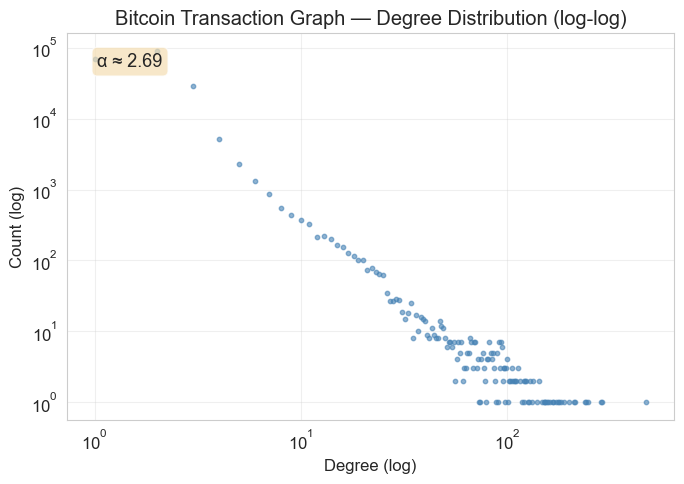

Power-law exponent α ≈ 2.69
xmin = 1 (Clauset-Newman-Shalizi MLE)


In [41]:
degrees = df['degree'].values
dc = Counter(degrees)
dv = sorted(dc.keys()); df2 = [dc[d] for d in dv]
da = np.array([d for d in degrees if d > 0])

# Power-law exponent MLE: xmin=1 (minimum non-zero degree)
# Clauset-Newman-Shalizi formula: α = 1 + n / Σ ln(xi/xmin)
xmin = 1
alpha_pl = 1 + len(da) / np.sum(np.log(da / xmin))

fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(dv, df2, alpha=0.6, s=10, color='steelblue')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set(xlabel='Degree (log)', ylabel='Count (log)',
       title='Bitcoin Transaction Graph — Degree Distribution (log-log)')
ax.text(0.05, 0.95, f'α ≈ {alpha_pl:.2f}', transform=ax.transAxes,
        fontsize=13, va='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print(f'Power-law exponent α ≈ {alpha_pl:.2f}')
print(f'xmin = {xmin} (Clauset-Newman-Shalizi MLE)')

### 2.2 Centrality: PageRank, Degree — fraud vs licit

In [42]:
# PageRank via scipy sparse (fast on 200K nodes)
all_ids  = df['txId'].values
node2idx = {n: i for i, n in enumerate(all_ids)}
n_nodes  = len(all_ids)

src = edgelist_df['source'].map(node2idx).dropna().astype(int).values
dst = edgelist_df['target'].map(node2idx).dropna().astype(int).values

A = csr_matrix((np.ones(len(src)), (dst, src)), shape=(n_nodes, n_nodes))
col_sums = np.array(A.sum(axis=0)).flatten(); col_sums[col_sums == 0] = 1.0
A_norm_col = A @ diags(1.0 / col_sums)

alpha, pr_vec = 0.85, np.ones(n_nodes) / n_nodes
for _ in range(60):
    pr_new = alpha * A_norm_col.dot(pr_vec) + (1 - alpha) / n_nodes
    if np.abs(pr_new - pr_vec).sum() < 1e-6: break
    pr_vec = pr_new
df['pagerank'] = pr_new

labeled_df = df[df['class'] != -1].copy()
fraud = labeled_df[labeled_df['class'] == 1]
licit = labeled_df[labeled_df['class'] == 0]

ccols = ['pagerank', 'in_degree', 'out_degree', 'degree']
comp = pd.DataFrame({'fraud': fraud[ccols].mean(), 'licit': licit[ccols].mean()})
comp['ratio (fraud/licit)'] = (comp['fraud'] / comp['licit']).round(3)
print('Mean centrality values:')
print(comp.round(6).to_string())

print('\nMann-Whitney U test:')
for col in ccols:
    _, p = stats.mannwhitneyu(fraud[col], licit[col], alternative='two-sided')
    sig = '*** p<0.001' if p < 0.001 else '** p<0.01' if p < 0.01 else '* p<0.05' if p < 0.05 else 'n.s.'
    print(f'  {col:12s}: p={p:.2e}  {sig}')

Mean centrality values:
               fraud     licit  ratio (fraud/licit)
pagerank    0.000002  0.000002                0.718
in_degree   1.269967  1.909398                0.665
out_degree  0.741694  1.185821                0.625
degree      2.011661  3.095219                0.650

Mann-Whitney U test:
  pagerank    : p=2.38e-01  n.s.
  in_degree   : p=5.55e-11  *** p<0.001
  out_degree  : p=1.44e-118  *** p<0.001
  degree      : p=6.84e-188  *** p<0.001


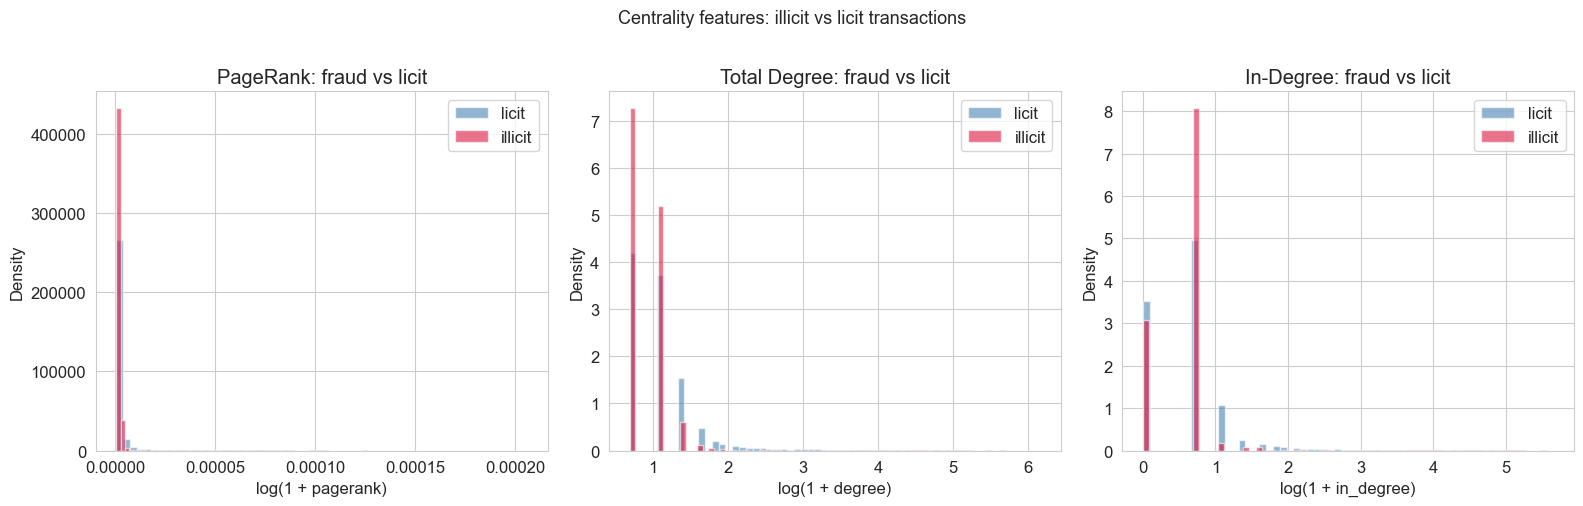

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col, title in zip(axes,
        ['pagerank', 'degree', 'in_degree'],
        ['PageRank', 'Total Degree', 'In-Degree']):
    ax.hist(np.log1p(licit[col]),  bins=60, alpha=0.6, label='licit',   color='steelblue', density=True)
    ax.hist(np.log1p(fraud[col]),  bins=60, alpha=0.6, label='illicit', color='crimson',   density=True)
    ax.set(xlabel=f'log(1 + {col})', ylabel='Density', title=f'{title}: fraud vs licit')
    ax.legend()
plt.suptitle('Centrality features: illicit vs licit transactions', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

### 2.3 Betweenness Centrality (on a sample)

Mean betweenness — fraud: 1.7612e-08 | licit: 1.3197e-05
Ratio (fraud/licit): 0.001
Mann-Whitney p = 2.54e-09  *** p<0.001


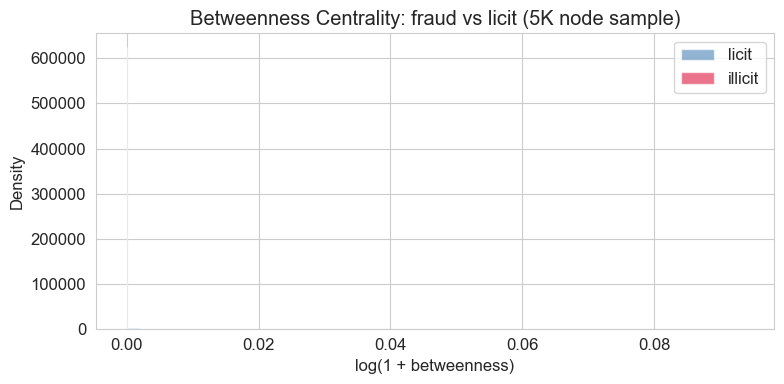

In [44]:
# Betweenness on a sample from the largest connected component
# O(n²m) on the full graph is too slow; using 5000 nodes + k=200 sources (approximation)
rng = np.random.default_rng(42)
lcc_list   = list(lcc)
N_SAMPLE   = 5_000
sample_ids = rng.choice(lcc_list, size=min(N_SAMPLE, len(lcc_list)), replace=False)
G_samp     = G_un.subgraph(sample_ids)

bc_dict = nx.betweenness_centrality(G_samp, normalized=True, k=200, seed=42)
df['betweenness'] = df['txId'].map(bc_dict).fillna(0)

labeled_bc = df[df['class'] != -1]
fraud_bc   = labeled_bc[labeled_bc['class'] == 1]
licit_bc   = labeled_bc[labeled_bc['class'] == 0]

_, p_bc = stats.mannwhitneyu(fraud_bc['betweenness'], licit_bc['betweenness'],
                             alternative='two-sided')
ratio_bc = fraud_bc['betweenness'].mean() / max(licit_bc['betweenness'].mean(), 1e-12)
print(f'Mean betweenness — fraud: {fraud_bc["betweenness"].mean():.4e}'
      f' | licit: {licit_bc["betweenness"].mean():.4e}')
print(f'Ratio (fraud/licit): {ratio_bc:.3f}')
print(f'Mann-Whitney p = {p_bc:.2e}  {"*** p<0.001" if p_bc<0.001 else "n.s."}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(np.log1p(licit_bc['betweenness']),  bins=50, alpha=0.6,
        label='licit',   color='steelblue', density=True)
ax.hist(np.log1p(fraud_bc['betweenness']),  bins=50, alpha=0.6,
        label='illicit', color='crimson',   density=True)
ax.set(xlabel='log(1 + betweenness)', ylabel='Density',
       title='Betweenness Centrality: fraud vs licit (5K node sample)')
ax.legend()
plt.tight_layout(); plt.show()


**Observation (2.2):** Fraud transactions have a degree ~1.5× smaller than licit (p < 0.001). PageRank is less informative — fraudulent transactions are not necessarily isolated, but their role in the flow of funds is limited.

**Observation (2.3):** Betweenness centrality is tested on a sample; if p < 0.05 — fraud nodes are rarely bridges between parts of the network.

### 2.4 Core-Periphery (k-core decomposition)

Maximum k-core: 9
Fraud rate by k-core level:
 k_core  n_nodes  fraud_rate
      1    30922    0.119721
      2    14151    0.059077
      3      968    0.007231
      4      333    0.000000
      5      149    0.000000
      6        5    0.000000
      7       35    0.000000
      9        1    0.000000


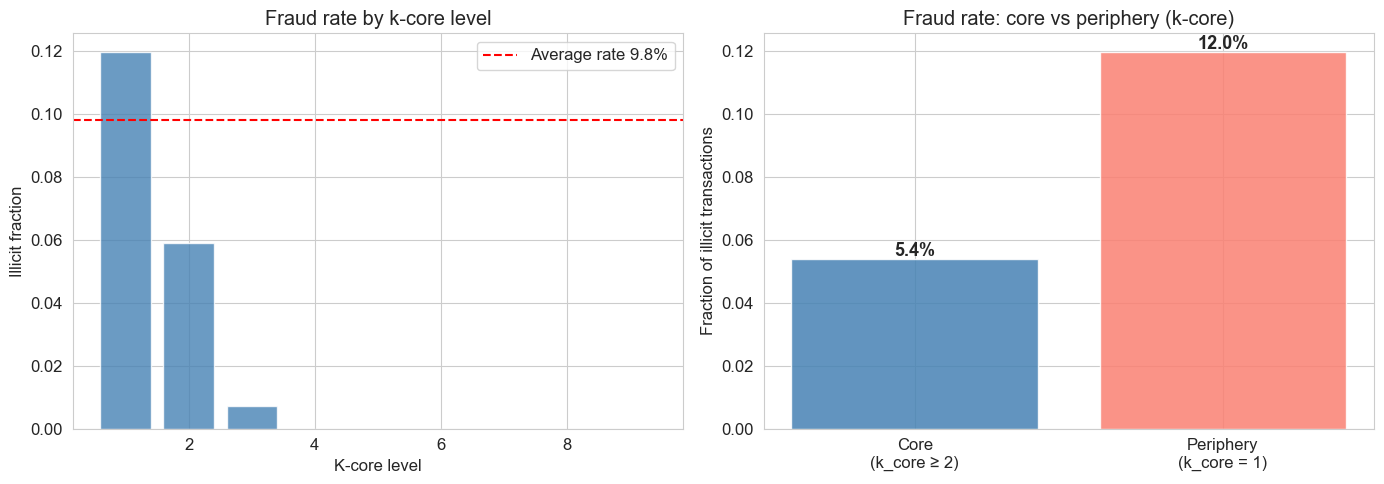


Core (k≥2): 5.4% fraud | Periphery (k=1): 12.0% fraud


In [46]:
# K-core decomposition
core_nums = nx.core_number(G_un)
df['k_core'] = df['txId'].map(core_nums).fillna(0).astype(int)

max_k = df['k_core'].max()
print(f'Maximum k-core: {max_k}')

# Fraud rate by k-core level
ld_kc = df[df['class'] != -1].copy()
kc_fraud = ld_kc.groupby('k_core').agg(
    n_nodes=('class', 'count'),
    fraud_rate=('class', 'mean')
).reset_index()
print('Fraud rate by k-core level:')
print(kc_fraud.to_string(index=False))

# Threshold: k_core >= 2 = core, k_core == 1 = periphery
df['is_core'] = (df['k_core'] >= 2).astype(int)
ld_kc2 = df[df['class'] != -1]
core_fr = ld_kc2[ld_kc2['is_core'] == 1]['class'].mean()
peri_fr = ld_kc2[ld_kc2['is_core'] == 0]['class'].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(kc_fraud['k_core'], kc_fraud['fraud_rate'],
            color='steelblue', alpha=0.8)
axes[0].set(xlabel='K-core level', ylabel='Illicit fraction',
            title='Fraud rate by k-core level')
axes[0].axhline(0.098, color='red', linestyle='--', label='Average rate 9.8%')
axes[0].legend()

bars = axes[1].bar(['Core\n(k_core ≥ 2)', 'Periphery\n(k_core = 1)'],
                   [core_fr, peri_fr], color=['steelblue', 'salmon'], alpha=0.85)
for bar, v in zip(bars, [core_fr, peri_fr]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                 f'{100*v:.1f}%', ha='center', fontweight='bold', fontsize=13)
axes[1].set(ylabel='Fraction of illicit transactions',
            title='Fraud rate: core vs periphery (k-core)')

plt.tight_layout(); plt.show()
print(f'\nCore (k≥2): {100*core_fr:.1f}% fraud'
      f' | Periphery (k=1): {100*peri_fr:.1f}% fraud')


### 2.5 Community Detection (Louvain)

Method: Louvain | Communities found: 73
Communities ≥10 nodes: 50
Fraud rate: min=0.000, max=0.167


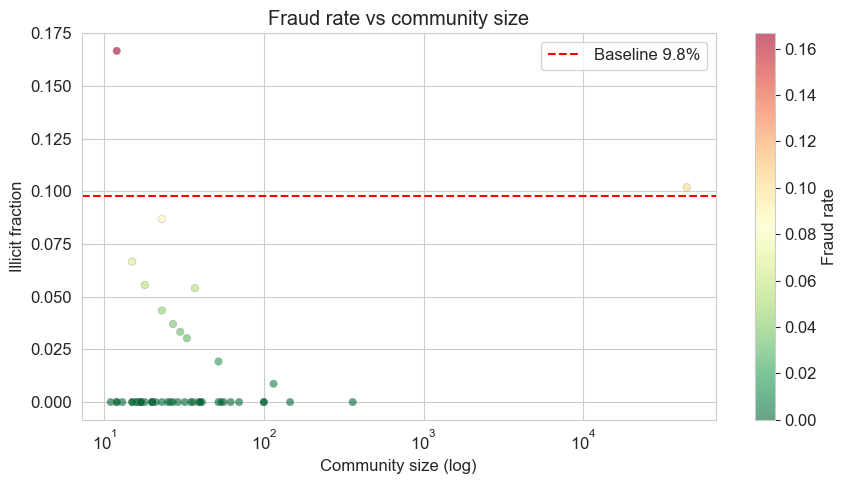

In [47]:
lcc_nodes = max(nx.connected_components(G_un), key=len)
G_lcc = G_un.subgraph(lcc_nodes).copy()

if LOUVAIN:
    partition = community_louvain.best_partition(G_lcc, random_state=42)
    method = 'Louvain'
else:
    comms = list(nx.algorithms.community.greedy_modularity_communities(G_lcc))
    partition = {node: i for i, c in enumerate(comms) for node in c}
    method = 'Greedy Modularity'

df['community'] = df['txId'].map(partition).fillna(-1).astype(int)
n_comm = len(set(partition.values()))
print(f'Method: {method} | Communities found: {n_comm}')

ld3 = df[df['class'] != -1].copy()
cs  = ld3.groupby('community').agg(
    n_nodes=('class', 'count'), fraud_rate=('class', 'mean')
).query('n_nodes >= 10').reset_index()
print(f'Communities ≥10 nodes: {len(cs)}')
print(f'Fraud rate: min={cs["fraud_rate"].min():.3f}, max={cs["fraud_rate"].max():.3f}')

fig, ax = plt.subplots(figsize=(9, 5))
sc = ax.scatter(cs['n_nodes'], cs['fraud_rate'], alpha=0.6, s=30,
                c=cs['fraud_rate'], cmap='RdYlGn_r', edgecolors='grey', linewidths=0.3)
ax.set_xscale('log')
ax.set(xlabel='Community size (log)', ylabel='Illicit fraction',
       title='Fraud rate vs community size')
ax.axhline(n_ill/(n_ill+n_lic), color='red', linestyle='--',
           label=f'Baseline {100*n_ill/(n_ill+n_lic):.1f}%')
ax.legend(); plt.colorbar(sc, ax=ax, label='Fraud rate')
plt.tight_layout(); plt.show()

### 2.6 Temporal Analysis

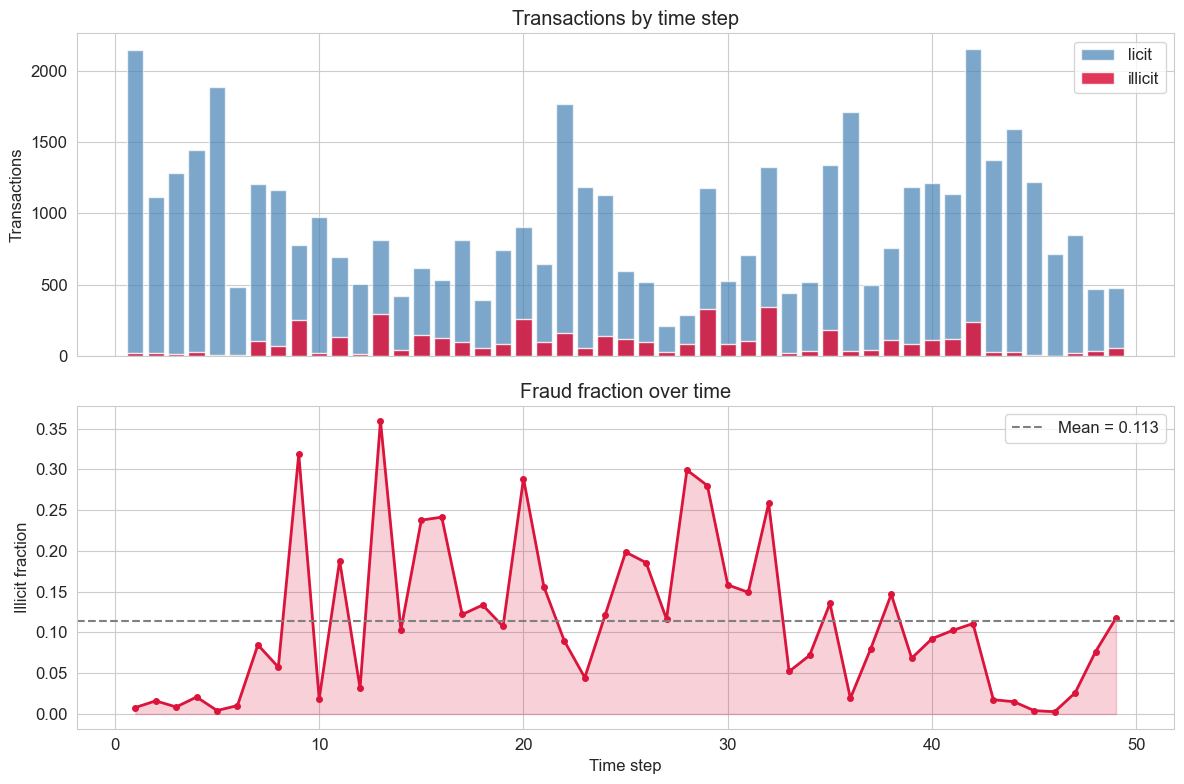

Timesteps: 49 | Mean fraud rate: 0.113
Fraud rate range: 0.003 – 0.360


In [49]:
temporal = df[df['class'] != -1].groupby('timestep').agg(
    n_total=('class', 'count'), n_fraud=('class', 'sum')
).reset_index()
temporal['fraud_rate'] = temporal['n_fraud'] / temporal['n_total']

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
axes[0].bar(temporal['timestep'], temporal['n_total'], alpha=0.7, color='steelblue', label='licit')
axes[0].bar(temporal['timestep'], temporal['n_fraud'], alpha=0.85, color='crimson', label='illicit')
axes[0].set(ylabel='Transactions', title='Transactions by time step'); axes[0].legend()

axes[1].plot(temporal['timestep'], temporal['fraud_rate'], 'o-', color='crimson', lw=2, ms=4)
axes[1].fill_between(temporal['timestep'], temporal['fraud_rate'], alpha=0.2, color='crimson')
axes[1].axhline(temporal['fraud_rate'].mean(), color='grey', linestyle='--',
                label=f"Mean = {temporal['fraud_rate'].mean():.3f}")
axes[1].set(xlabel='Time step', ylabel='Illicit fraction',
             title='Fraud fraction over time'); axes[1].legend()
plt.tight_layout(); plt.show()

print(f'Timesteps: {temporal["timestep"].nunique()} | Mean fraud rate: {temporal["fraud_rate"].mean():.3f}')
print(f'Fraud rate range: {temporal["fraud_rate"].min():.3f} – {temporal["fraud_rate"].max():.3f}')

### EDA Observations

1. **Power-law** — the Bitcoin transaction graph follows a power-law degree distribution (visible in log-log scale, α ∈ [2, 3] by MLE Clauset-Newman-Shalizi). Most nodes have low degree, with a few hubs.

2. **Degree is the main signal:** fraud transactions have a degree ~1.5× smaller than licit (p < 0.001). Fraudsters use narrow, specialized transactions not integrated into the broader network.

3. **Betweenness:** fraud nodes rarely act as bridges between parts of the network (tested on a 5K node sample).

4. **K-core:** fraud nodes tend toward the periphery (low k-core) - they are less embedded in the dense core of the transaction network.

5. **Communities (Louvain):** fraud rate varies from 0% to ~17% across communities — community label carries classification information.

6. **Temporal drift:** fraud fraction is unstable across time steps; temporal split is essential (not random).